In [3]:
import numpy as np
import pandas as pd

In [81]:
print("numpy=="+np.__version__)
print("pandas=="+pd.__version__)

numpy==2.4.6
pandas==2.3.3


In [4]:
df = pd.read_csv("/kaggle/input/datasets/sohaibdevv/how-creatine-and-mass-gainers-are-helping-people/supplement_impact_data.csv")

# Data Understanding

In [5]:
df.head()

,ID,Age,Gender,Supplement,Weeks,Initial_WT,Final_WT,Strength_Gain,Primary_Benefit
0,1,61,Non-Binary,Mass Gainer,10,74.0,80.8,8%,Cognitive Support
1,2,60,Female,Both,10,74.1,79.0,28%,Weight Gain
2,3,41,Non-Binary,Both,21,61.0,70.9,25%,Strength Gain
3,4,32,Non-Binary,Both,18,83.3,91.3,19%,Weight Gain
4,5,37,Male,Mass Gainer,17,92.4,98.8,5%,Muscle Recovery


In [6]:
df.tail()

,ID,Age,Gender,Supplement,Weeks,Initial_WT,Final_WT,Strength_Gain,Primary_Benefit
995,996,51,Female,Mass Gainer,11,59.0,63.6,8%,Muscle Recovery
996,997,44,Non-Binary,Creatine Monohydrate,9,59.2,60.2,25%,Strength Gain
997,998,49,Male,Creatine Monohydrate,10,52.0,53.6,14%,Bone Density
998,999,22,Male,Both,4,66.8,77.1,17%,Weight Gain
999,1000,57,Male,Mass Gainer,16,68.6,78.4,10%,Cognitive Support


In [7]:
df.sample(10)

,ID,Age,Gender,Supplement,Weeks,Initial_WT,Final_WT,Strength_Gain,Primary_Benefit
246,247,55,Non-Binary,Mass Gainer,8,94.1,99.8,7%,Cognitive Support
0,1,61,Non-Binary,Mass Gainer,10,74.0,80.8,8%,Cognitive Support
630,631,40,Male,Both,19,54.9,63.8,26%,Cognitive Support
67,68,46,Female,Mass Gainer,7,57.9,63.9,10%,Cognitive Support
522,523,42,Male,Mass Gainer,4,90.6,95.3,10%,Cognitive Support
398,399,43,Female,Creatine Monohydrate,12,76.7,78.4,15%,Strength Gain
841,842,53,Non-Binary,Mass Gainer,7,53.2,61.6,9%,Weight Gain
623,624,48,Male,Mass Gainer,18,89.1,97.1,9%,Muscle Recovery
885,886,64,Female,Mass Gainer,13,64.2,72.6,6%,Weight Gain
325,326,24,Female,Mass Gainer,22,62.6,69.8,12%,Muscle Recovery


In [8]:
df.shape

(1000, 9)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

ID                 0
Age                0
Gender             0
Supplement         0
Weeks              0
Initial_WT         0
Final_WT           0
Strength_Gain      0
Primary_Benefit    0
dtype: int64

In [11]:
df = df.drop(columns=["ID"])

In [12]:
df['difference_found_in_WT'] = df["Final_WT"]-df["Initial_WT"]
df = df.drop(columns=["Final_WT"])

In [13]:
df.head()

,Age,Gender,Supplement,Weeks,Initial_WT,Strength_Gain,Primary_Benefit,difference_found_in_WT
0,61,Non-Binary,Mass Gainer,10,74.0,8%,Cognitive Support,6.8
1,60,Female,Both,10,74.1,28%,Weight Gain,4.9
2,41,Non-Binary,Both,21,61.0,25%,Strength Gain,9.9
3,32,Non-Binary,Both,18,83.3,19%,Weight Gain,8.0
4,37,Male,Mass Gainer,17,92.4,5%,Muscle Recovery,6.4


In [14]:
df.rename(columns={"Strength_Gain":"Strength_Gain(%)"},inplace=True)

In [15]:
df["Strength_Gain(%)"] = df["Strength_Gain(%)"].str.replace("%","").astype(int)

In [16]:
df.head()

,Age,Gender,Supplement,Weeks,Initial_WT,Strength_Gain(%),Primary_Benefit,difference_found_in_WT
0,61,Non-Binary,Mass Gainer,10,74.0,8,Cognitive Support,6.8
1,60,Female,Both,10,74.1,28,Weight Gain,4.9
2,41,Non-Binary,Both,21,61.0,25,Strength Gain,9.9
3,32,Non-Binary,Both,18,83.3,19,Weight Gain,8.0
4,37,Male,Mass Gainer,17,92.4,5,Muscle Recovery,6.4


In [17]:
df.dtypes

Age                         int64
Gender                     object
Supplement                 object
Weeks                       int64
Initial_WT                float64
Strength_Gain(%)            int64
Primary_Benefit            object
difference_found_in_WT    float64
dtype: object

In [18]:
df.describe()

,Age,Weeks,Initial_WT,Strength_Gain(%),difference_found_in_WT
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.807000,13.741000,75.356700,16.377000,5.446600
std,13.994556,5.869273,14.492468,7.241776,3.316572
min,18.000000,4.000000,50.000000,5.000000,0.500000
25%,29.000000,9.000000,62.600000,10.000000,2.000000
50%,41.500000,14.000000,75.350000,17.000000,5.600000
75%,54.000000,19.000000,87.800000,22.000000,8.200000
max,65.000000,24.000000,99.900000,30.000000,12.000000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1000 non-null   int64  
 1   Gender                  1000 non-null   object 
 2   Supplement              1000 non-null   object 
 3   Weeks                   1000 non-null   int64  
 4   Initial_WT              1000 non-null   float64
 5   Strength_Gain(%)        1000 non-null   int64  
 6   Primary_Benefit         1000 non-null   object 
 7   difference_found_in_WT  1000 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 62.6+ KB


In [20]:
df.select_dtypes(include=["int"]).drop(columns=["Strength_Gain(%)"]).columns

Index(['Age', 'Weeks'], dtype='object')

In [21]:
df.select_dtypes(include=["float"]).columns

Index(['Initial_WT', 'difference_found_in_WT'], dtype='object')

In [22]:
df.select_dtypes(include=["object"]).columns

Index(['Gender', 'Supplement', 'Primary_Benefit'], dtype='object')

In [23]:
num_cols = df.select_dtypes(include=["int","float"]).drop(columns=["Strength_Gain(%)"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns
tar_col = df["Strength_Gain(%)"]

# Exploratory Data Analysis

In [82]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
print("matplotlib=="+matplotlib.__version__)
print("seaborn=="+sns.__version__)

matplotlib==3.10.0
seaborn==0.13.2


**Univariate Analysis**

*Numeric Columns*

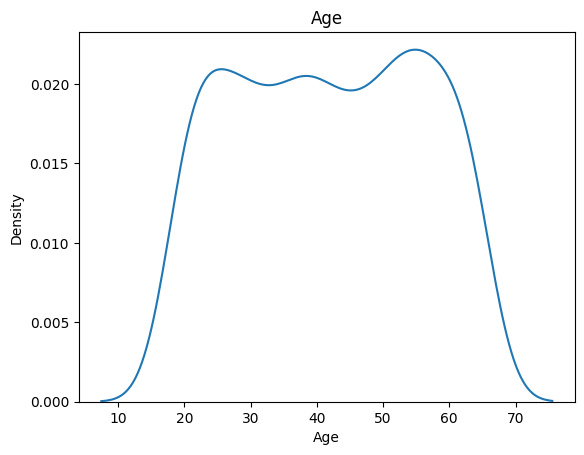

-0.01914139181610422


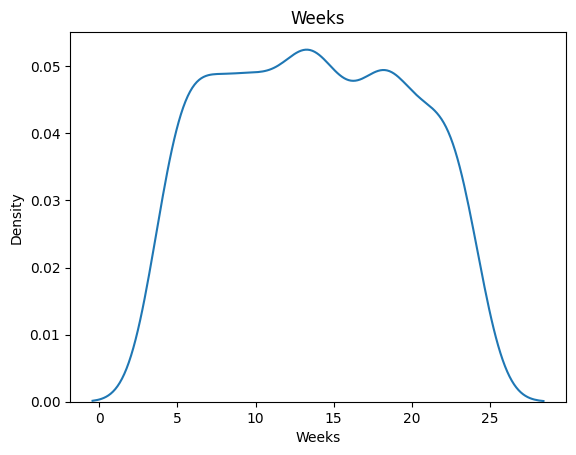

0.03263203440811148


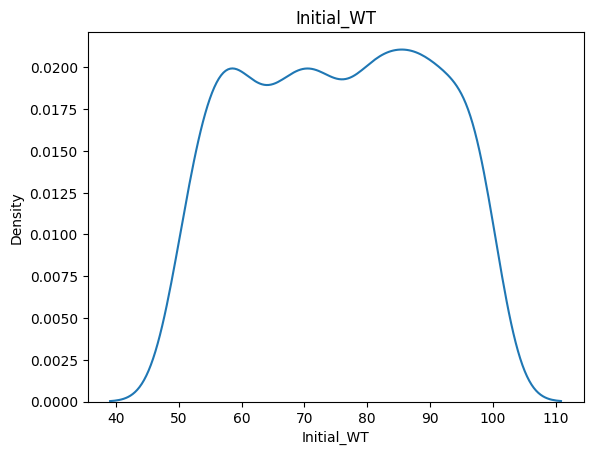

-0.029633904215323935


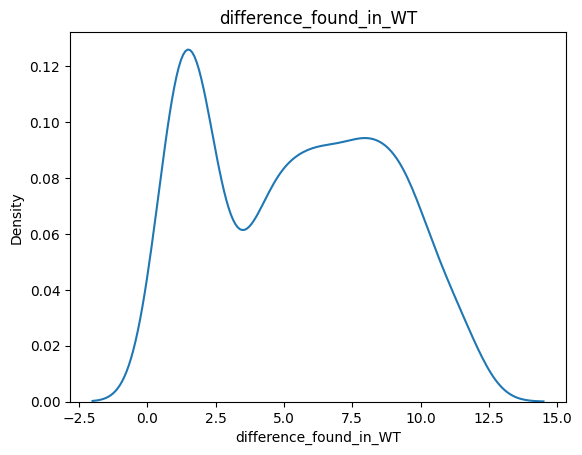

0.0919058227772009


In [25]:
right_skewed_cols = []
left_skewed_cols = []
nrml_num_cols = []
for col in num_cols:
    sns.kdeplot(x=col,data=df)
    plt.title(col)
    plt.show()
    print(df[col].skew())
    if df[col].skew()>=0.6:
        right_skewed_cols.append(col)
    elif df[col].skew()<=-0.6:
        left_skewed_cols.append(col)
    else:
        nrml_num_cols.append(col)

In [26]:
print(f"right skewed cols: {right_skewed_cols}")
print(f"left skewed cols: {left_skewed_cols}")
print(f"nrml skewed cols: {nrml_num_cols}")

right skewed cols: []
left skewed cols: []
nrml skewed cols: ['Age', 'Weeks', 'Initial_WT', 'difference_found_in_WT']


* All numeric columns are almost perfect nrml skewed

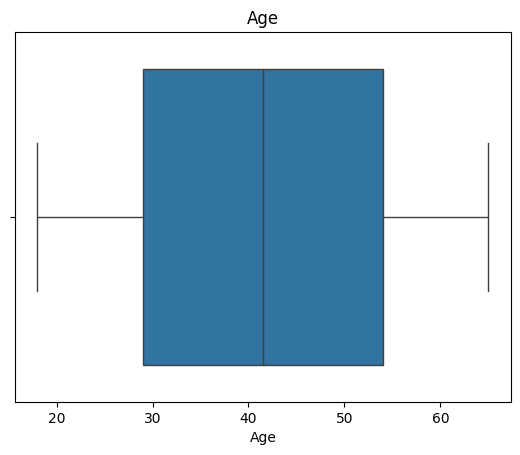

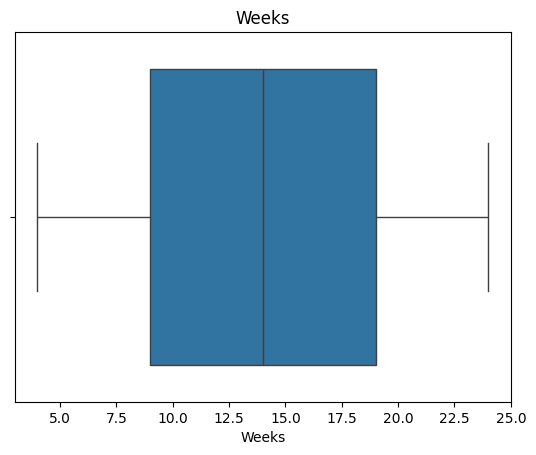

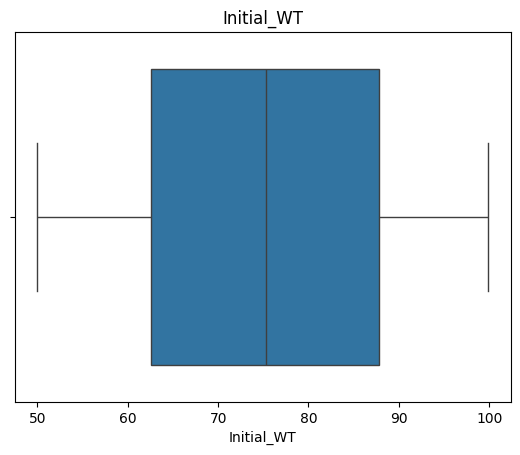

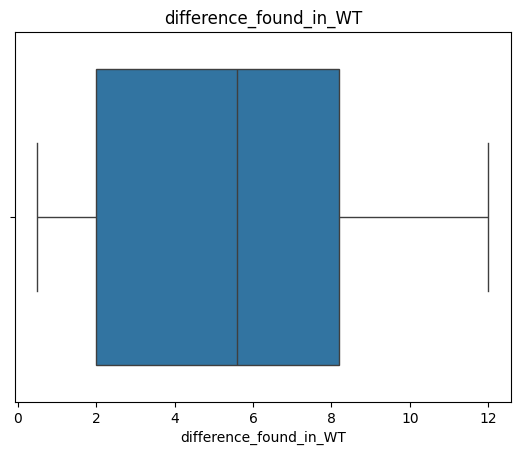

In [27]:
for col in num_cols:
    sns.boxplot(x=col,data=df)
    plt.title(col)
    plt.show()

* No outliers found

*Categorical Columns*

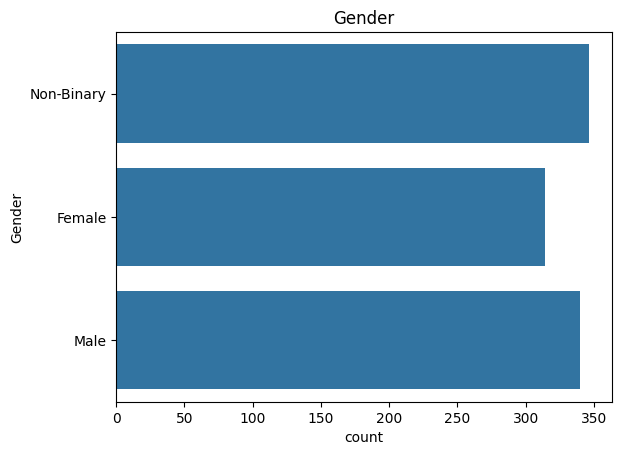

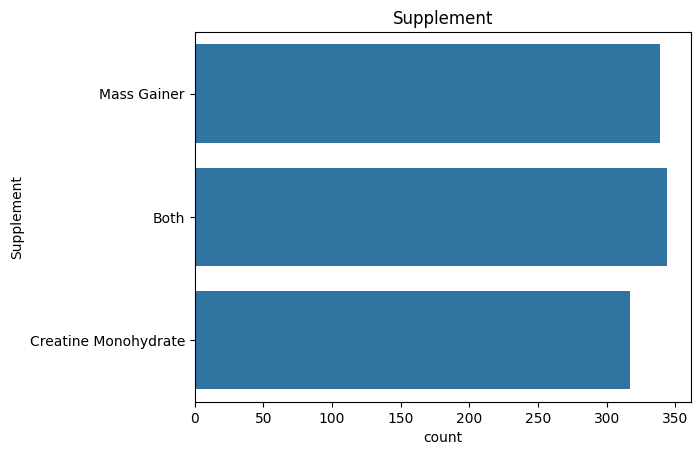

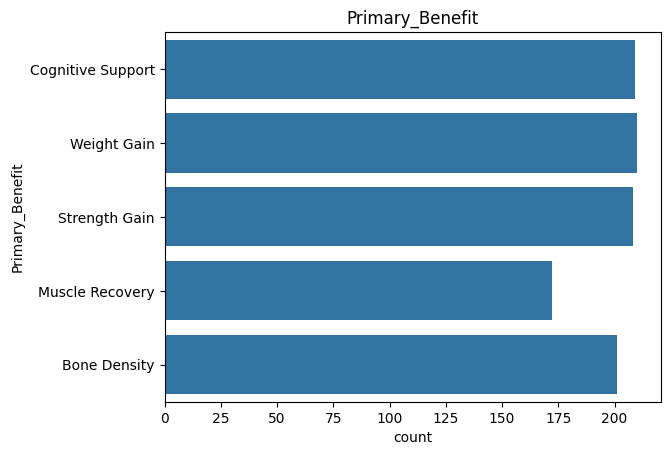

In [28]:
for col in cat_cols:
    sns.countplot(y=col,data=df)
    plt.title(col)
    plt.show()

* Almost all are balanced

*Target Column*

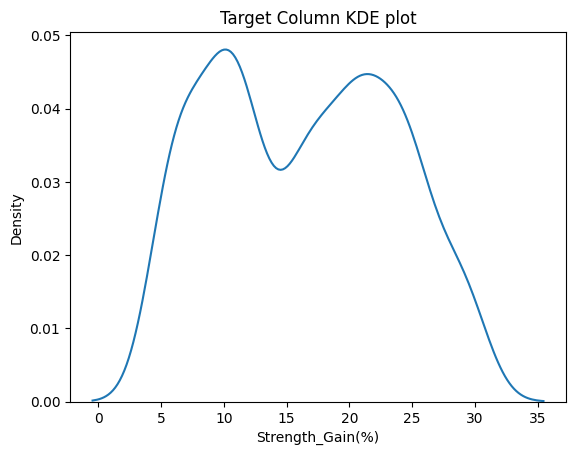

Target col skew: 0.08815491876264019


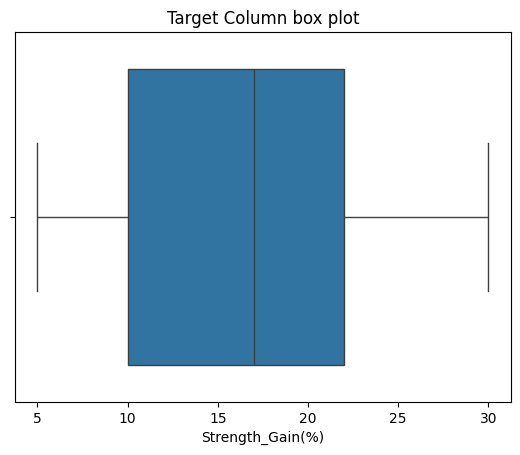

In [29]:
sns.kdeplot(x=tar_col,data=df)
plt.title("Target Column KDE plot")
plt.show()
print(f"Target col skew: {df["Strength_Gain(%)"].skew()}")
sns.boxplot(x=tar_col,data=df)
plt.title("Target Column box plot")
plt.show()

Target column:

* Equal distribution, no skewness
* Has no outliers

**Bivariate Analysis**

*Numeric Columns*

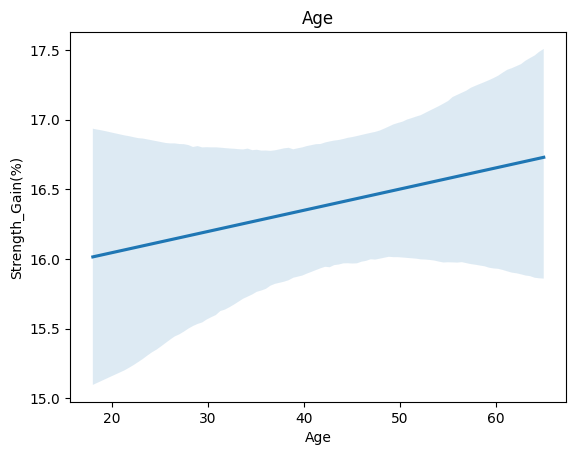

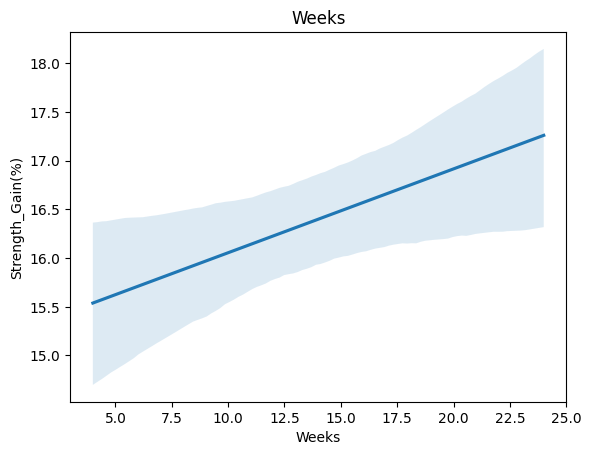

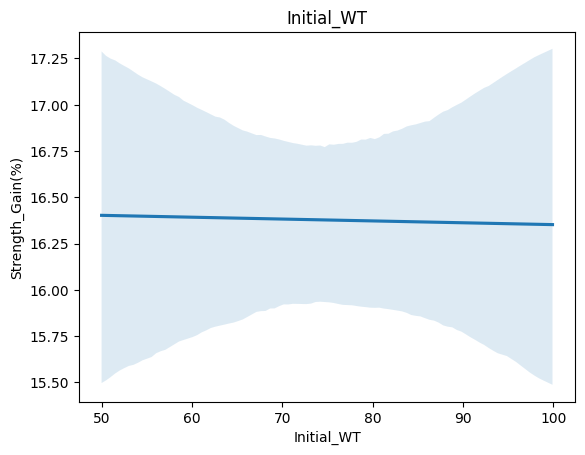

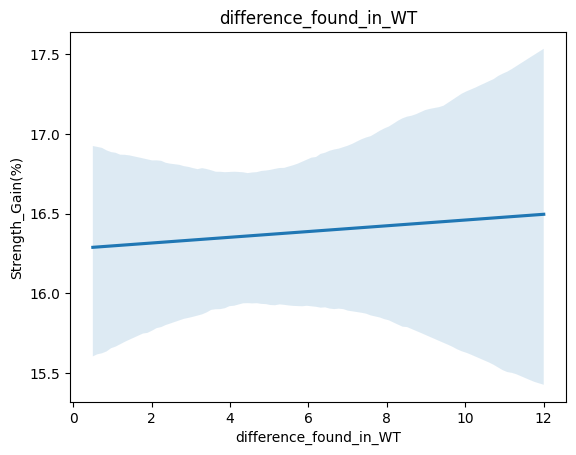

In [30]:
for col in num_cols:
    sns.regplot(x=col,y=tar_col,data=df,scatter=False)
    plt.title(col)
    plt.show()

* Age and weeks features are clearly increasing the Strength_Gain(%) value as they are increaseing 📈
* Initial_WT: as it increases the target value decreases (almost straight line)
* difference_found_in_WT: as it increases the target value increases (almost straight line)

*Categorical Columns*

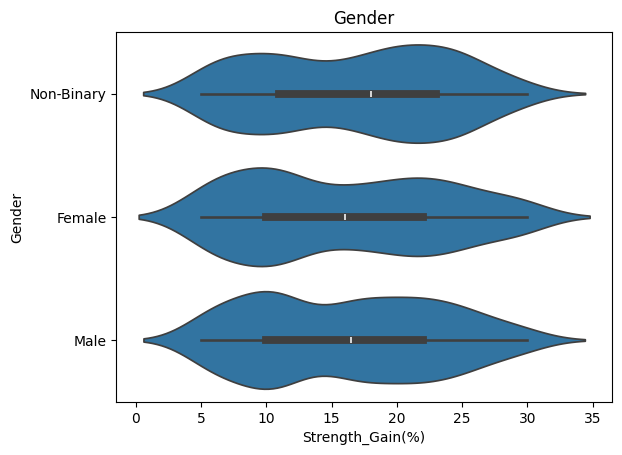

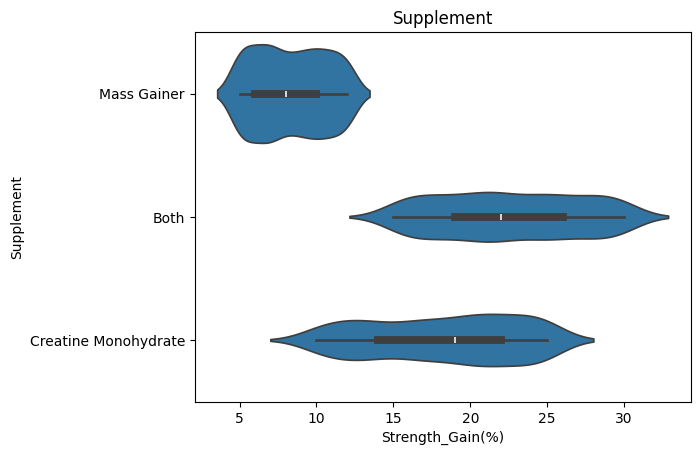

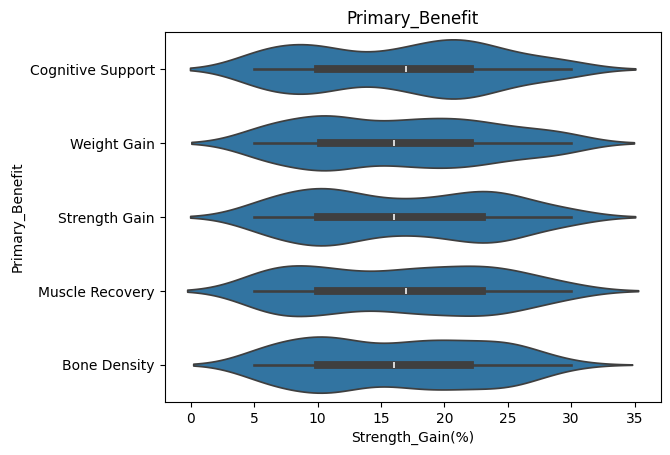

In [31]:
for col in cat_cols:
    sns.violinplot(y=col,x=tar_col,data=df)
    plt.title(col)
    plt.show()

* Supplement feature is clearly seprating target value through its categories:
   1. Mass Gainer --> range from approx 5-13 of Strength_Gain(%)
   2. Creatine Monohydrate --> range from approx 7-28 of Strength_Gain(%)
   3. Both --> range from approx 12-30 of Strength_Gain(%)
* Gender and Primary_Benifit are showing  very less sepration

**Multivariate Analysis**

*Multicollinearity Detection*

<Axes: >

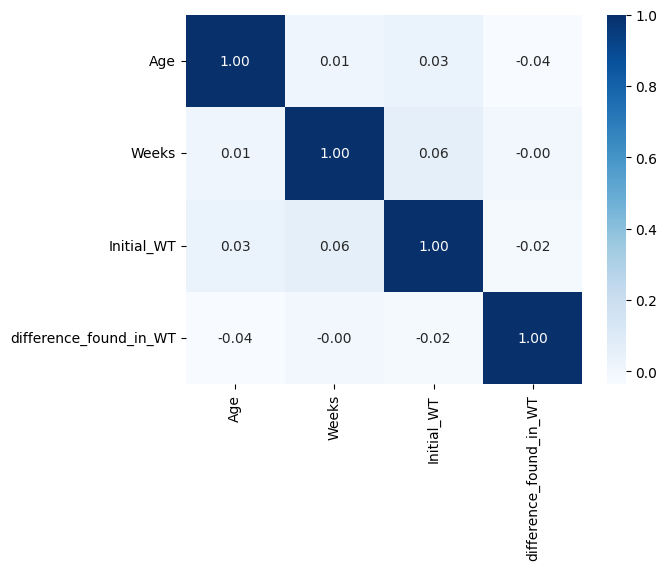

In [32]:
sns.heatmap(df[num_cols].corr(),annot=True,fmt=".2f",cmap="Blues")

* There is no multicollinearity 

# Preprocessing

In [84]:
import sklearn
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,root_mean_squared_error,r2_score,mean_absolute_error
import optuna

In [86]:
print("sklearn=="+sklearn.__version__)
print("xgboost=="+xgboost.__version__)
print("optuna=="+optuna.__version__)

sklearn==1.6.1
xgboost==3.2.0
optuna==4.8.0


In [34]:
df.sample(1)

,Age,Gender,Supplement,Weeks,Initial_WT,Strength_Gain(%),Primary_Benefit,difference_found_in_WT
435,52,Male,Creatine Monohydrate,7,64.0,18,Bone Density,2.0


In [35]:
x = df.drop(columns=["Strength_Gain(%)"])
y = df["Strength_Gain(%)"]

# Train Test Split

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Pipelines for every type of columns seprately

In [37]:
nrml_num_pipeline = Pipeline(steps=[
    ("num_imputer",SimpleImputer(strategy="mean")),
    ("scaling",StandardScaler())    
])

In [38]:
cat_pipeline = Pipeline(steps=[
    ("cat_imputer",SimpleImputer(strategy="most_frequent")),
    ("OHEncoder",OneHotEncoder(drop="if_binary",handle_unknown="ignore"))
])

# Preprocessing ColumnTransformer

In [39]:
preprocessing = ColumnTransformer(transformers=[
    ("nrml_num_pipeline",nrml_num_pipeline,nrml_num_cols),
    ("cat_pipeline",cat_pipeline,cat_cols)
],remainder="passthrough")

# Finding best model with best params (Optuna)

In [40]:
def objective(trial):
    model_name = trial.suggest_categorical("model", ["lr", "dt", "rf", "xgb"])

    if model_name == "lr":
        model = LinearRegression()

    elif model_name == "dt":
        model = DecisionTreeRegressor(
        max_depth=trial.suggest_int("max_depth", 3, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10)
    )

    elif model_name == "rf":
        model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 5, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        n_jobs=-1
    )

    elif model_name == "xgb":
        model = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        gamma=trial.suggest_float("gamma", 0, 5),
        reg_alpha=trial.suggest_float("reg_alpha", 0, 5),
        reg_lambda=trial.suggest_float("reg_lambda", 0, 5),
        n_jobs=-1,
        verbosity=0
    )

    pipeline = Pipeline(steps=[
        ("preprocessing",preprocessing),
        ("model",model)
    ])

    score = cross_val_score(pipeline,x_train,y_train,cv=5,scoring="neg_mean_squared_error")
    return score.mean()

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=100)

[I 2026-06-16 16:20:00,185] A new study created in memory with name: no-name-5d2581e1-c82c-407e-ba66-d83cd474eeec
[I 2026-06-16 16:20:00,363] Trial 0 finished with value: -16.714847818658992 and parameters: {'model': 'lr'}. Best is trial 0 with value: -16.714847818658992.
[I 2026-06-16 16:20:00,529] Trial 1 finished with value: -16.714847818658992 and parameters: {'model': 'lr'}. Best is trial 0 with value: -16.714847818658992.
[I 2026-06-16 16:20:00,681] Trial 2 finished with value: -24.316288123408704 and parameters: {'model': 'dt', 'max_depth': 18, 'min_samples_split': 11, 'min_samples_leaf': 6}. Best is trial 0 with value: -16.714847818658992.
[I 2026-06-16 16:20:03,074] Trial 3 finished with value: -17.302633396497402 and parameters: {'model': 'rf', 'n_estimators': 159, 'max_depth': 17, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: -16.714847818658992.
[I 2026-06-16 16:20:07,921] Trial 4 finished with value: -17.24930956467900

In [ ]:
params = study.best_params
params

In [ ]:
model_name = params["model"]

if model_name == "lr":
    final_model = LinearRegression()

elif model_name == "dt":
    final_model = DecisionTreeRegressor(
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"]
    )

elif model_name == "rf":
    final_model = RandomForestRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        n_jobs=-1
    )

elif model_name == "xgb":
    final_model = XGBRegressor(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        gamma=params["gamma"],
        reg_alpha=params["reg_alpha"],
        reg_lambda=params["reg_lambda"],
        n_jobs=-1,
        verbosity=0
    )

# Final Pipeline (preprocessing + best model with best params)

In [ ]:
final_pipeline = Pipeline(steps=[
    ("preprocessing",preprocessing),
    ("final_model",final_model)
])

# Training 

In [ ]:
final_pipeline.fit(x_train,y_train)

# Predicting on test data

In [ ]:
y_train_pred = final_pipeline.predict(x_train)
y_test_pred = final_pipeline.predict(x_test)

# Model Evaluation

**Mean squared error**

In [ ]:
train_mse = mean_squared_error(y_train,y_train_pred)
print(f"Train MSE: {train_mse}")
test_mse = mean_squared_error(y_test,y_test_pred)
print(f"Test MSE: {test_mse}")

**Root mean squared error**

In [ ]:
train_rmse = root_mean_squared_error(y_train,y_train_pred)
print(f"Train RMSE: {train_rmse}")
test_rmse = root_mean_squared_error(y_test,y_test_pred)
print(f"Test RMSE: {test_rmse}")

**NRMSE std**

In [ ]:
train_nrmse_std = train_rmse / y_train.std()
print(f"Train NRMSE std: {train_nrmse_std}")
test_nrmse_std = test_rmse / y_test.std()
print(f"Test NRMSE std: {test_nrmse_std}")

**NRMSE mean**

In [ ]:
train_nrmse_mean = train_rmse / y_train.mean()
print(f"Train NRMSE mean: {train_nrmse_mean}")
test_nrmse_mean = test_rmse / y_test.mean()
print(f"Test NRMSE mean: {test_nrmse_mean}")

**NRMSE range**

In [ ]:
train_nrmse_range = train_rmse / (y_train.max()-y_train.min())
print(f"Train NRMSE range: {train_nrmse_range}")
test_nrmse_range = test_rmse / (y_test.max()-y_test.min())
print(f"Test NRMSE range: {test_nrmse_range}")

**Mean absolute error**

In [ ]:
train_mae = mean_absolute_error(y_train,y_train_pred)
print(f"Train MAE: {train_mae}")
test_mae = mean_absolute_error(y_test,y_test_pred)
print(f"Test MAE: {test_mae}")

**R2 score**

In [ ]:
train_r2 = r2_score(y_train,y_train_pred)
print(f"Train r2: {train_r2}")
test_r2 = r2_score(y_test,y_test_pred)
print(f"Test r2: {test_r2}")

# Saving the final_pipeline

In [ ]:
import joblib
joblib.dump(final_pipeline,"final_pipeline.pkl")

In [87]:
print("joblib=="+joblib.__version__)

joblib==1.5.3


# Model Explaination (Shap)

In [ ]:
import shap

In [88]:
print("shap=="+shap.__version__)

shap==0.51.0


In [ ]:
shap_preprocessor = final_pipeline.named_steps["preprocessing"]
shap_model = final_pipeline.named_steps["final_model"]

In [ ]:
feature_names = []
for col in shap_preprocessor.get_feature_names_out():
    feature_names.append(col.split("__")[-1])

In [ ]:
x_train_t = pd.DataFrame(
    shap_preprocessor.transform(x_train),
    columns=feature_names
)

In [ ]:
x_test_t = pd.DataFrame(
    shap_preprocessor.transform(x_test),
    columns=feature_names
)

In [ ]:
explainer = shap.Explainer(shap_model,x_train_t)

In [ ]:
shap_values = explainer(x_test_t)

In [ ]:
shap.plots.bar(shap_values,max_display=len(feature_names))

In [ ]:
shap.plots.beeswarm(shap_values,max_display=len(feature_names))

# Correlation Checking when all column values are in numbers

In [ ]:
plt.figure(figsize=(10, 10))
combined_num_df = pd.concat([x_test_t, y_test.rename("target")], axis=1)
sns.heatmap(combined_num_df.corr(),annot=True,fmt=".2f",cmap="Blues")
plt.show